In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [3]:
df = pd.read_csv('/content/drive/MyDrive/AIML_lab_sem4/exp 11,12/dataset_diabetes_exp_11.csv')

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.shape

(768, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)
df.fillna(df.median(), inplace=True)

In [8]:

scaler = StandardScaler()
X = scaler.fit_transform(df.drop('Outcome', axis=1))
y = df['Outcome']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
dt= DecisionTreeClassifier(random_state=42)


In [11]:
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [12]:
y_pred_dt = dt.predict(X_test)

In [13]:
accuracy = accuracy_score(y_test, y_pred_dt)
precision = precision_score(y_test, y_pred_dt)
recall = recall_score(y_test, y_pred_dt)
f1 = f1_score(y_test, y_pred_dt)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.7143
Precision: 0.5965
Recall: 0.6182
F1 Score: 0.6071


In [14]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.78      0.77      0.78        99
           1       0.60      0.62      0.61        55

    accuracy                           0.71       154
   macro avg       0.69      0.69      0.69       154
weighted avg       0.72      0.71      0.72       154



In [15]:
from sklearn.metrics import confusion_matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

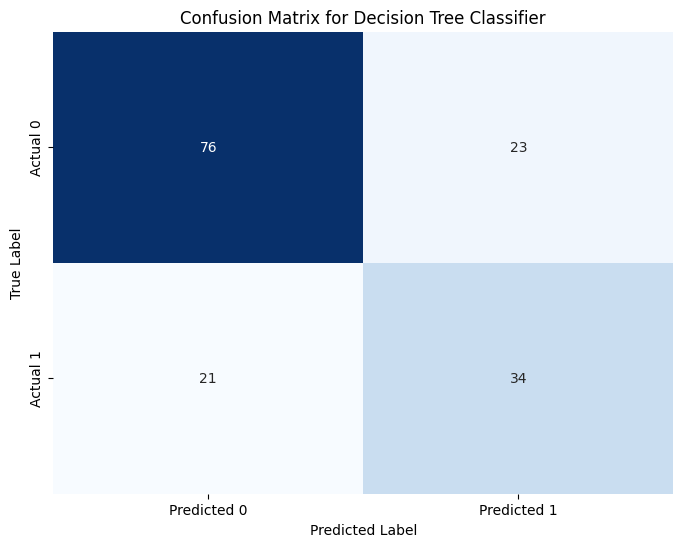

In [17]:


plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Decision Tree Classifier')
plt.show()

In [18]:
rf = RandomForestClassifier(n_estimators = 100 ,random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [19]:
y_pred_rf = rf.predict(X_test)

In [20]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

In [21]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Classifier Metrics:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1 Score: {f1_rf:.4f}")

Random Forest Classifier Metrics:
Accuracy: 0.7403
Precision: 0.6316
Recall: 0.6545
F1 Score: 0.6429


In [22]:
print("\nClassification Report for Random Forest Classifier:")
print(classification_report(y_test, y_pred_rf))


Classification Report for Random Forest Classifier:
              precision    recall  f1-score   support

           0       0.80      0.79      0.80        99
           1       0.63      0.65      0.64        55

    accuracy                           0.74       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.74      0.74      0.74       154



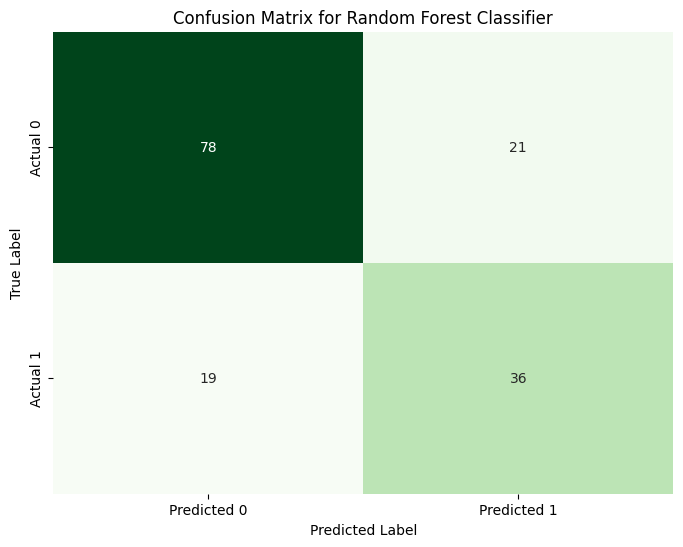

In [23]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Random Forest Classifier')
plt.show()

In [24]:
bagging_classifier = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42), n_estimators=200, random_state=42)
bagging_classifier.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  n_estimators=200, random_state=42)

In [25]:
y_pred_bagging = bagging_classifier.predict(X_test)

In [26]:
cm_bagging = confusion_matrix(y_test, y_pred_bagging)

In [27]:
accuracy_bagging = accuracy_score(y_test, y_pred_bagging)
precision_bagging = precision_score(y_test, y_pred_bagging)
recall_bagging = recall_score(y_test, y_pred_bagging)
f1_bagging = f1_score(y_test, y_pred_bagging)

print("Bagging Classifier Metrics (50 Decision Trees):")
print(f"Accuracy: {accuracy_bagging:.4f}")
print(f"Precision: {precision_bagging:.4f}")
print(f"Recall: {recall_bagging:.4f}")
print(f"F1 Score: {f1_bagging:.4f}")

Bagging Classifier Metrics (50 Decision Trees):
Accuracy: 0.7727
Precision: 0.6724
Recall: 0.7091
F1 Score: 0.6903


In [28]:
print("\nClassification Report for Bagging Classifier:")
print(classification_report(y_test, y_pred_bagging))


Classification Report for Bagging Classifier:
              precision    recall  f1-score   support

           0       0.83      0.81      0.82        99
           1       0.67      0.71      0.69        55

    accuracy                           0.77       154
   macro avg       0.75      0.76      0.76       154
weighted avg       0.78      0.77      0.77       154



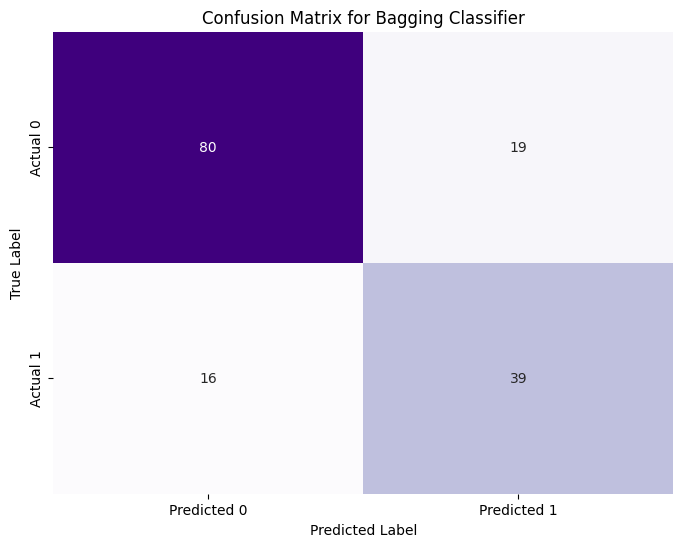

In [29]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm_bagging, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Bagging Classifier')
plt.show()

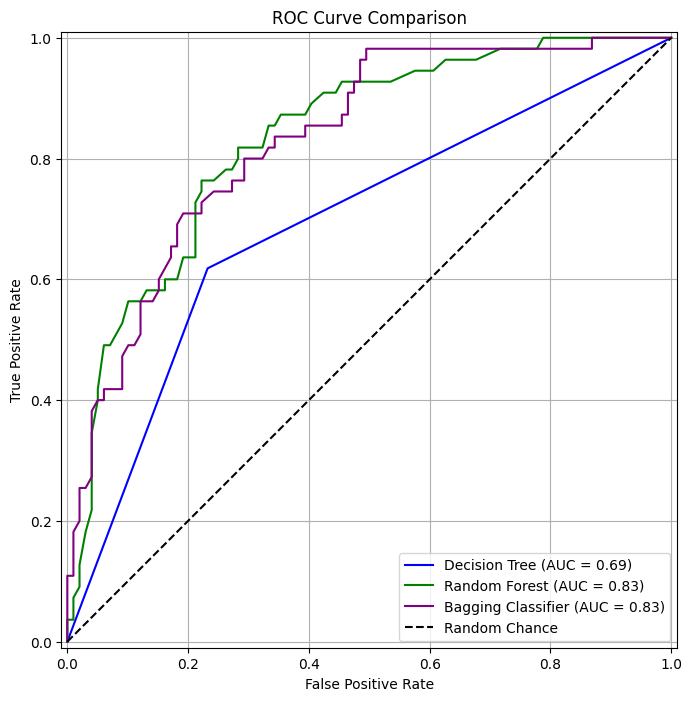

In [30]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

plt.figure(figsize=(10, 8))

probs_dt = dt.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, probs_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)
RocCurveDisplay(fpr=fpr_dt, tpr=tpr_dt, roc_auc=roc_auc_dt, estimator_name='Decision Tree').plot(ax=plt.gca(), color='blue')

probs_rf = rf.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, probs_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
RocCurveDisplay(fpr=fpr_rf, tpr=tpr_rf, roc_auc=roc_auc_rf, estimator_name='Random Forest').plot(ax=plt.gca(), color='green')

probs_bagging = bagging_classifier.predict_proba(X_test)[:, 1]
fpr_bagging, tpr_bagging, _ = roc_curve(y_test, probs_bagging)
roc_auc_bagging = auc(fpr_bagging, tpr_bagging)
RocCurveDisplay(fpr=fpr_bagging, tpr=tpr_bagging, roc_auc=roc_auc_bagging, estimator_name='Bagging Classifier').plot(ax=plt.gca(), color='purple')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

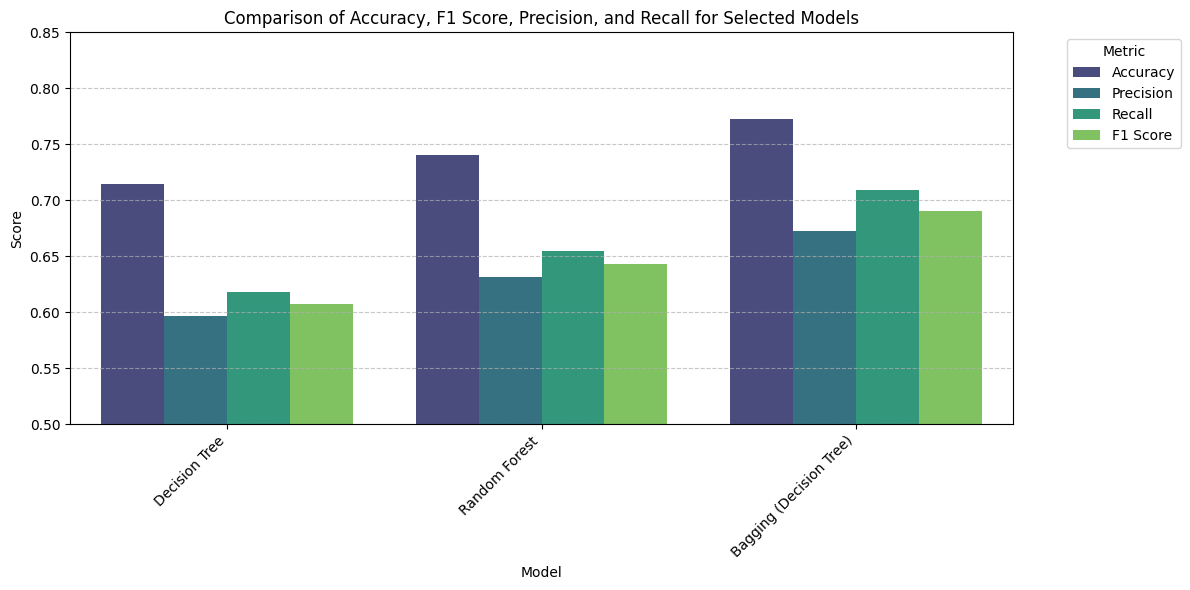

In [34]:
selected_models = ['Decision Tree', 'Random Forest', 'Bagging (Decision Tree)']
filtered_metrics_df = metrics_df[metrics_df['Model'].isin(selected_models)]

plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Score', hue='Metric', data=filtered_metrics_df, palette='viridis')
plt.title('Comparison of Accuracy, F1 Score, Precision, and Recall for Selected Models')
plt.ylabel('Score')
plt.ylim(0.5, 0.85)
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
import pickle
with open('/content/drive/MyDrive/AIML_lab_sem4/exp 11,12/Exp11_models/decision_tree_model.pkl', 'wb') as file:
    pickle.dump(dt, file)

In [ ]:

with open('/content/drive/MyDrive/AIML_lab_sem4/exp 11,12/Exp11_models/random_forest_model.pkl', 'wb') as file:
    pickle.dump(rf, file)

In [ ]:

with open('/content/drive/MyDrive/AIML_lab_sem4/exp 11,12/Exp11_models/bagging_classifier_model.pkl', 'wb') as file:
    pickle.dump(bagging_classifier, file)
